# World Cup Agent Arena | Agent Stoppage Time | Exploratory Data Analysis

## Imports and Setup 

In [1]:
# Imports 
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

In [ ]:
# Credentials
ARENA_KEY      = "your_arena_key_here"
GEMINI_API_KEY = "your_gemini_api_key_here"

In [3]:
# Endpoints
ARENA            = "https://staging.stair-ai.com"
SPORTMONKS_PROXY = f"{ARENA}/api/v1/data/proxy/sportmonks/v3/football"
POLYMARKET_GAMMA = f"{ARENA}/api/v1/data/proxy/polymarket-gamma"
POLYMARKET_CLOB  = f"{ARENA}/api/v1/data/proxy/polymarket-clob"
SUPABASE         = "https://ezvbmtvrvzageqixvdak.supabase.co"
SUPABASE_KEY     = "sb_publishable__m8bOkD05ToFwATpaWST5w_2-3fGS7V"

In [4]:
# Headers
H_ARENA  = {"x-api-key": ARENA_KEY}
H_PUBLIC = {"apikey": SUPABASE_KEY}
H_WCA    = {"apikey": SUPABASE_KEY, "Accept-Profile": "world_cup_arena"}

In [5]:
# Constants
SEASON_ID          = 26618      # WC 2026
SPORTMONKS_FIXTURE_ID = 19609127   # Mexico vs South Africa

## Section 1. Sportmonks - Raw Fetch

Fetch the fixture with all available includes and inspect the raw shape what keys came back, how many rows in each array, before we look at anything in detail.

In [6]:
r = requests.get(
    f"{SPORTMONKS_PROXY}/fixtures/{SPORTMONKS_FIXTURE_ID}",
    params={"include": "participants;predictions;odds;xgfixture"},
    headers=H_ARENA, timeout=15,
)
r.raise_for_status()

fixture = r.json()["body"]["data"]

In [7]:
# Raw shape 
print(f"HTTP {r.status_code} OK\n")
print("Top-level keys in fixture:")
for key, val in fixture.items():
    if isinstance(val, list):
        print(f"  {key:20s} → list of {len(val)} items")
    elif isinstance(val, dict):
        print(f"  {key:20s} → dict with keys: {list(val.keys())}")
    else:
        print(f"  {key:20s} → {val}")

HTTP 200 OK

Top-level keys in fixture:
  id                   → 19609127
  sport_id             → 1
  league_id            → 732
  season_id            → 26618
  stage_id             → 77478590
  group_id             → 253019
  aggregate_id         → None
  round_id             → 395361
  state_id             → 1
  venue_id             → 1599
  name                 → Mexico vs South Africa
  starting_at          → 2026-06-11 19:00:00
  result_info          → None
  leg                  → 1/1
  details              → Match 1
  length               → 90
  placeholder          → False
  has_odds             → True
  has_premium_odds     → True
  starting_at_timestamp → 1781204400
  participants         → list of 2 items
  predictions          → list of 28 items
  odds                 → list of 2340 items
  xgfixture            → list of 0 items


### Section 1a. Participants

Extract the two teams from the fixture and inspect their fields.

In [8]:
# Pull participants
participants = fixture["participants"]

# Look at raw keys first
print("Keys in a participant row:")
print(list(participants[0].keys()))

Keys in a participant row:
['id', 'sport_id', 'country_id', 'venue_id', 'gender', 'name', 'short_code', 'image_path', 'founded', 'type', 'placeholder', 'last_played_at', 'meta']


In [9]:
# Extract useful fields from each participant
rows = []
for p in participants:
    rows.append({
        "id":             p["id"],
        "sport_id":       p["sport_id"],
        "country_id":     p["country_id"],
        "venue_id":       p["venue_id"],
        "gender":         p["gender"],
        "name":           p["name"],
        "short_code":     p["short_code"],
        "image_path":     p["image_path"],
        "founded":        p["founded"],
        "type":           p["type"],
        "placeholder":    p["placeholder"],
        "last_played_at": p["last_played_at"],
        "meta":           p["meta"],
    })

df_participants = pd.DataFrame(rows)
display(df_participants)

,id,sport_id,country_id,venue_id,gender,name,short_code,image_path,founded,type,placeholder,last_played_at,meta
0,18576,1,458,14659,male,Mexico,MEX,https://cdn.sportmonks.com/images/soccer/teams...,1927,national,False,2026-06-05 02:00:00,"{'location': 'home', 'winner': None, 'position..."
1,18555,1,146,1519,male,South Africa,ZAF,https://cdn.sportmonks.com/images/soccer/teams...,1991,national,False,2026-05-29 16:00:00,"{'location': 'away', 'winner': None, 'position..."


In [10]:
df_participants["meta"].apply(lambda x: display(x))

{'location': 'home', 'winner': None, 'position': 2}

{'location': 'away', 'winner': None, 'position': 3}

0    None
1    None
Name: meta, dtype: object

### Section 1b. ML Predictions

Sportmonks runs multiple ML models against each fixture.

In [11]:
predictions = fixture["predictions"]

print(f"Total prediction rows: {len(predictions)}\n")
print("Keys in a prediction row:")
print(list(predictions[0].keys()))
print("\nFirst raw row:")
print(json.dumps(predictions[0], indent=2))

Total prediction rows: 28

Keys in a prediction row:
['id', 'fixture_id', 'predictions', 'type_id']

First raw row:
{
  "id": 27413319,
  "fixture_id": 19609127,
  "predictions": {
    "yes": 42.49,
    "no": 57.51
  },
  "type_id": 235
}


In [12]:
# See every unique prediction shape across all 28 rows
print("All prediction shapes by type_id:\n")
for p in predictions:
    print(f"  type_id {p['type_id']:4d} → keys: {list(p['predictions'].keys())}")

All prediction shapes by type_id:

  type_id  235 → keys: ['yes', 'no']
  type_id  327 → keys: ['yes', 'no']
  type_id  326 → keys: ['yes', 'no']
  type_id  332 → keys: ['yes', 'no']
  type_id  231 → keys: ['yes', 'no']
  type_id  232 → keys: ['home_home', 'home_away', 'home_draw', 'away_home', 'away_away', 'away_draw', 'draw_draw', 'draw_home', 'draw_away']
  type_id  233 → keys: ['home', 'away', 'draw']
  type_id  334 → keys: ['yes', 'no']
  type_id  328 → keys: ['yes', 'no']
  type_id 1690 → keys: ['yes', 'no', 'equal']
  type_id  240 → keys: ['scores']
  type_id  331 → keys: ['yes', 'no']
  type_id  330 → keys: ['yes', 'no']
  type_id  333 → keys: ['yes', 'no']
  type_id 1683 → keys: ['yes', 'no', 'equal']
  type_id  234 → keys: ['yes', 'no']
  type_id 1679 → keys: ['yes', 'no']
  type_id 1685 → keys: ['yes', 'no', 'equal']
  type_id 1684 → keys: ['yes', 'no', 'equal']
  type_id  237 → keys: ['home', 'away', 'draw']
  type_id  238 → keys: ['home', 'away', 'draw']
  type_id  239 → k

In [13]:
# Extract only the 1X2 models
one_x_two = [p for p in predictions if "home" in p["predictions"] and "draw" in p["predictions"]]

print(f"1X2 models found: {len(one_x_two)}\n")
for p in one_x_two:
    probs = p["predictions"]
    print(f"  type_id {p['type_id']} → home: {probs['home']}%  draw: {probs['draw']}%  away: {probs['away']}%  (sum: {round(probs['home']+probs['draw']+probs['away'], 1)}%)")

1X2 models found: 3

  type_id 233 → home: 28.4%  draw: 46.08%  away: 25.52%  (sum: 100.0%)
  type_id 237 → home: 40.84%  draw: 27.78%  away: 31.38%  (sum: 100.0%)
  type_id 238 → home: 50.35%  draw: 9.54%  away: 40.11%  (sum: 100.0%)


In [14]:
# Build dataframe
df_1x2 = pd.DataFrame([
    {
        "type_id": str(p["type_id"]),
        "home (MEX)": p["predictions"]["home"],
        "draw":       p["predictions"]["draw"],
        "away (ZAF)": p["predictions"]["away"],
    }
    for p in one_x_two
])

display(df_1x2)

,type_id,home (MEX),draw,away (ZAF)
0,233,28.40,46.08,25.52
1,237,40.84,27.78,31.38
2,238,50.35,9.54,40.11


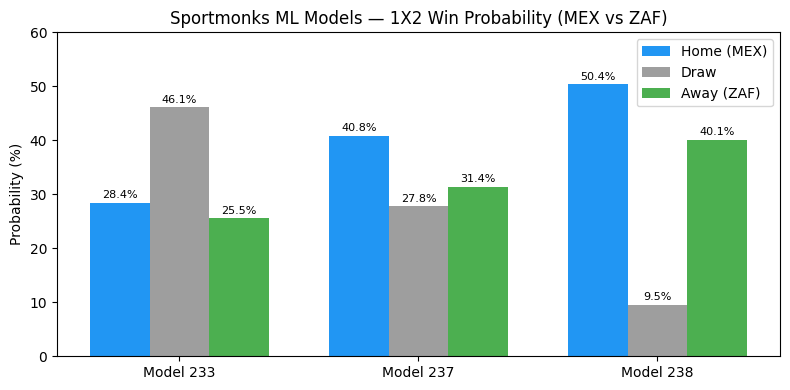

In [15]:
# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(df_1x2))
width = 0.25

ax.bar([i - width for i in x], df_1x2["home (MEX)"], width=width, label="Home (MEX)", color="#2196F3")
ax.bar([i          for i in x], df_1x2["draw"],       width=width, label="Draw",       color="#9E9E9E")
ax.bar([i + width for i in x], df_1x2["away (ZAF)"], width=width, label="Away (ZAF)", color="#4CAF50")

ax.set_xticks(list(x))
ax.set_xticklabels([f"Model {t}" for t in df_1x2["type_id"]])
ax.set_ylabel("Probability (%)")
ax.set_title("Sportmonks ML Models — 1X2 Win Probability (MEX vs ZAF)")
ax.legend()
ax.set_ylim(0, 60)

for bar in ax.patches:
    ax.annotate(f"{bar.get_height():.1f}%",
                (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Section 1c · Bookmaker Odds

2182 rows — one per bookmaker × outcome × market.
We filter to market_id == 1 (the 1X2 / Full-Time-Result market) only, then explore what the bookmakers collectively think about this match.

In [16]:
odds = fixture["odds"]

print(f"Total odds rows: {len(odds)}\n")
print("Keys in an odds row:")
print(list(odds[0].keys()))
print("\nFirst raw row:")
print(json.dumps(odds[0], indent=2))

Total odds rows: 2340

Keys in an odds row:
['id', 'fixture_id', 'market_id', 'bookmaker_id', 'label', 'value', 'name', 'sort_order', 'market_description', 'probability', 'dp3', 'fractional', 'american', 'winning', 'stopped', 'total', 'handicap', 'participants', 'created_at', 'original_label', 'latest_bookmaker_update']

First raw row:
{
  "id": 236516629559,
  "fixture_id": 19609127,
  "market_id": 88,
  "bookmaker_id": 2,
  "label": "Away/Yes",
  "value": "4.00",
  "name": "1st Half",
  "sort_order": 4,
  "market_description": "To Score In Half",
  "probability": "25%",
  "dp3": "4.000",
  "fractional": "4",
  "american": "300",
  "winning": false,
  "stopped": false,
  "total": null,
  "handicap": null,
  "participants": null,
  "created_at": "2026-05-23T09:50:23.000000Z",
  "original_label": null,
  "latest_bookmaker_update": "2026-06-06 10:50:52"
}


In [17]:
# How many unique markets exist in these 2182 rows?
market_counts = {}
for o in odds:
    mid = o["market_id"]
    desc = o.get("market_description") or "unknown"
    market_counts[mid] = desc

print(f"Unique markets: {len(market_counts)}\n")
for mid, desc in sorted(market_counts.items()):
    print(f"  market_id {mid:4d} → {desc}")

Unique markets: 98

  market_id    1 → Fulltime Result
  market_id    2 → Double Chance
  market_id    6 → Asian Handicap
  market_id    7 → Goal Line
  market_id   10 → Draw No Bet
  market_id   11 → Last Team to Score
  market_id   13 → Result/Both Teams to Score
  market_id   14 → Both Teams to Score
  market_id   15 → Both Teams to Score in 1st Half
  market_id   16 → Both Teams to Score in 2nd Half
  market_id   17 → Clean Sheet
  market_id   18 → Home Team Exact Goals
  market_id   19 → Away Team Exact Goals
  market_id   26 → 1st Half Asian Handicap
  market_id   27 → 1st Half Goal Line
  market_id   28 → 1st Half Goals
  market_id   29 → Half Time/Full Time
  market_id   30 → Half Time Correct Score
  market_id   31 → Half Time Result
  market_id   32 → 1st Half Handicap
  market_id   33 → Exact 1st Half Goals
  market_id   34 → 10 Minute Result
  market_id   37 → Result / Total Goals
  market_id   38 → Exact 2nd Half Goals
  market_id   40 → To Win Both Halves
  market_id   42

In [18]:
# Filter to market_id == 1 only
odds_1x2 = [o for o in odds if o["market_id"] == 1]

print(f"Total odds rows    : {len(odds)}")
print(f"1X2 market rows   : {len(odds_1x2)}")
print(f"Other markets rows : {len(odds) - len(odds_1x2)}\n")

# How many unique bookmakers in the 1X2 market?
bookmakers = set(o["bookmaker_id"] for o in odds_1x2)
print(f"Unique bookmakers in 1X2 market: {len(bookmakers)}")
print(f"Bookmaker IDs: {sorted(bookmakers)}")

Total odds rows    : 2340
1X2 market rows   : 48
Other markets rows : 2292

Unique bookmakers in 1X2 market: 16
Bookmaker IDs: [2, 9, 13, 14, 16, 20, 27, 28, 29, 32, 34, 35, 38, 58, 64, 66]


In [19]:
# Build clean dataframe for 1X2 odds
odds_rows = []
for o in odds_1x2:
    prob_raw = (o.get("probability") or "0").replace("%", "").strip()
    odds_rows.append({
        "bookmaker_id": o["bookmaker_id"],
        "outcome":      o["label"],
        "decimal odds": float(o.get("value") or 0),
        "implied prob": round(float(prob_raw), 1),
        "updated":      (o.get("latest_bookmaker_update") or "")[:16],
    })

df_odds = pd.DataFrame(odds_rows).sort_values(["bookmaker_id", "outcome"])
display(df_odds)

,bookmaker_id,outcome,decimal odds,implied prob,updated
45,2,Away,7.50,13.3,2026-06-06 10:50
0,2,Draw,4.20,23.8,2026-06-06 10:50
44,2,Home,1.44,69.2,2026-06-06 10:50
17,9,Away,8.50,11.8,2026-06-06 10:44
16,9,Draw,4.50,22.2,2026-06-06 10:44
15,9,Home,1.36,73.5,2026-06-06 10:44
38,13,Away,7.50,13.3,2026-06-06 10:45
26,13,Draw,4.33,23.1,2026-06-06 10:45
25,13,Home,1.44,69.4,2026-06-06 10:45
37,14,Away,7.80,12.8,2026-06-06 10:44


In [20]:
# Compute consensus (mean) and spread (min/max) per outcome
summary = df_odds.groupby("outcome")["implied prob"].agg(
    mean="mean",
    min="min",
    max="max",
    std="std"
).round(2).reset_index()

print("── Bookmaker consensus ──")
display(summary)

# Spot the outlier — bookmaker 27 is stale (updated 2026-05-26, rest are 2026-06-06)
print("\n── Stale bookmakers (not updated today) ──")
display(df_odds[~df_odds["updated"].str.startswith("2026-06-06")])

── Bookmaker consensus ──


,outcome,mean,min,max,std
0,Away,12.72,11.5,14.8,1.00
1,Draw,23.08,22.0,25.0,0.84
2,Home,70.08,66.7,73.5,1.64



── Stale bookmakers (not updated today) ──


,bookmaker_id,outcome,decimal odds,implied prob,updated
42,27,Away,6.75,14.8,2026-05-26 20:20
41,27,Draw,4.30,23.3,2026-05-26 20:20
4,27,Home,1.50,66.7,2026-05-26 20:20


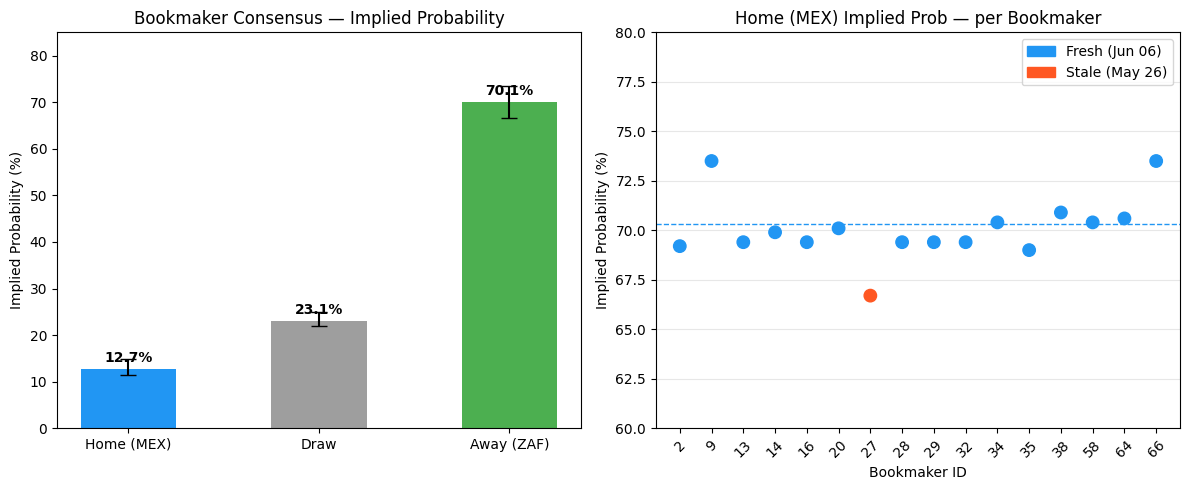

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: consensus bar chart with error bars ──────────────────
outcomes  = ["Home (MEX)", "Draw", "Away (ZAF)"]
means     = summary["mean"].values
mins      = summary["min"].values
maxs      = summary["max"].values
colors    = ["#2196F3", "#9E9E9E", "#4CAF50"]

bars = axes[0].bar(outcomes, means, color=colors, width=0.5)
axes[0].errorbar(
    outcomes, means,
    yerr=[means - mins, maxs - means],
    fmt="none", color="black", capsize=6, linewidth=1.5
)
axes[0].set_title("Bookmaker Consensus — Implied Probability")
axes[0].set_ylabel("Implied Probability (%)")
axes[0].set_ylim(0, 85)
for bar, mean in zip(bars, means):
    axes[0].annotate(f"{mean:.1f}%",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5),
                     ha="center", fontsize=10, fontweight="bold")

# ── Right: scatter — every bookmaker's Home implied prob ────────
home_odds = df_odds[df_odds["outcome"] == "Home"].copy()
home_odds["stale"] = home_odds["updated"].apply(
    lambda x: "Stale (May 26)" if not x.startswith("2026-06-06") else "Fresh (Jun 06)"
)

colors_scatter = home_odds["stale"].map(
    {"Fresh (Jun 06)": "#2196F3", "Stale (May 26)": "#FF5722"}
)
axes[1].scatter(
    home_odds["bookmaker_id"].astype(str),
    home_odds["implied prob"],
    c=colors_scatter, s=80, zorder=3
)
axes[1].axhline(
    home_odds[home_odds["stale"] == "Fresh (Jun 06)"]["implied prob"].mean(),
    color="#2196F3", linestyle="--", linewidth=1, label="Fresh mean"
)
axes[1].set_title("Home (MEX) Implied Prob — per Bookmaker")
axes[1].set_xlabel("Bookmaker ID")
axes[1].set_ylabel("Implied Probability (%)")
axes[1].set_ylim(60, 80)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

fresh = mpatches.Patch(color="#2196F3", label="Fresh (Jun 06)")
stale = mpatches.Patch(color="#FF5722", label="Stale (May 26)")
axes[1].legend(handles=[fresh, stale])

plt.tight_layout()
plt.show()

## Section 2. Polymarket - Market Structure

Polymarket exposes two APIs:
- Gamma: returns the event + 3 child markets (condition ids + token ids)
- CLOB: returns the live mid price per YES token

We fetch both and explore the raw structure.

In [22]:
# Step 1: resolve the fixture → polymarket slug
r = requests.get(
    f"{ARENA}/api/v1/web/mapping",
    params={"fixture_id": SPORTMONKS_FIXTURE_ID},
    headers=H_ARENA, timeout=10,
)
r.raise_for_status()

mappings = r.json().get("mappings") or []
polymarket_event_slug = mappings[0]["polymarket_event_slug"] if mappings else None

print(f"HTTP {r.status_code} OK")
print(f"Slug: {polymarket_event_slug}")
print(f"\nRaw mapping response:")
print(json.dumps(r.json(), indent=2))

HTTP 200 OK
Slug: fifwc-mex-rsa-2026-06-11

Raw mapping response:
{
  "mappings": [
    {
      "away_country": "South Africa",
      "away_short_code": "ZAF",
      "home_country": "Mexico",
      "home_short_code": "MEX",
      "match_confidence": "high",
      "polymarket_away_condition_id": "0x17dfc75726fa95d4054d91e80295c8b3e494569617e67a7e620e27562b7952b0",
      "polymarket_away_token_yes": "115307860962719805060784163204351769077176612029040401546976102705811910754396",
      "polymarket_draw_condition_id": "0x0a4b9beb6128863db2b107f185521597a426356f1d9a23c7001401edfd32014b",
      "polymarket_draw_token_yes": "11634144673803325466643188834337300341803737096067092239834760823912726000274",
      "polymarket_event_slug": "fifwc-mex-rsa-2026-06-11",
      "polymarket_event_ticker": "fifwc-mex-rsa-2026-06-11",
      "polymarket_home_condition_id": "0x4cd77d456c83e7d8c569a8fb8f6396c3f40154f657e6d970733e2b1b6a7110ff",
      "polymarket_home_token_yes": "20779063998268474490699884714

In [23]:
import datetime
ts = 1781204400000 / 1000   # convert ms to seconds
print(datetime.datetime.utcfromtimestamp(ts))

2026-06-11 19:00:00


In [24]:
r = requests.get(
    f"{POLYMARKET_GAMMA}/events",
    params={"slug": polymarket_event_slug},
    headers=H_ARENA, timeout=15,
)
r.raise_for_status()

events = r.json().get("body") or []
event  = events[0] if events else None

print(f"HTTP {r.status_code} OK")
print(f"Events returned: {len(events)}\n")
print("Top-level keys in event:")
for key, val in event.items():
    if isinstance(val, list):
        print(f"  {key:25s} → list of {len(val)} items")
    elif isinstance(val, dict):
        print(f"  {key:25s} → dict")
    else:
        print(f"  {key:25s} → {val}")

HTTP 200 OK
Events returned: 1

Top-level keys in event:
  id                        → 351715
  ticker                    → fifwc-mex-rsa-2026-06-11
  slug                      → fifwc-mex-rsa-2026-06-11
  title                     → Mexico vs. South Africa
  description               → This event is for the upcoming FIFA World Cup game, scheduled for Thursday, June 11, 2026 between Mexico and South Africa.
  resolutionSource          → https://www.fifa.com/fifaplus/en/tournaments/mens/worldcup
  startDate                 → 2026-04-06T22:48:47.767995Z
  creationDate              → 2026-04-06T22:48:47.767989Z
  endDate                   → 2026-06-11T19:00:00Z
  image                     → https://polymarket-upload.s3.us-east-2.amazonaws.com/soccer ball-bba4025f77.png
  icon                      → https://polymarket-upload.s3.us-east-2.amazonaws.com/soccer ball-bba4025f77.png
  active                    → True
  closed                    → False
  archived                  → False
  new 

In [25]:
print(f"Number of child markets: {len(event['markets'])}\n")
print("Keys in a market row:")
print(list(event["markets"][0].keys()))
print("\nFirst raw market:")
print(json.dumps(event["markets"][0], indent=2))

Number of child markets: 3

Keys in a market row:
['id', 'question', 'conditionId', 'slug', 'resolutionSource', 'endDate', 'liquidity', 'startDate', 'image', 'icon', 'description', 'outcomes', 'outcomePrices', 'volume', 'active', 'closed', 'marketMakerAddress', 'createdAt', 'updatedAt', 'new', 'featured', 'submitted_by', 'archived', 'resolvedBy', 'restricted', 'groupItemTitle', 'groupItemThreshold', 'questionID', 'enableOrderBook', 'orderPriceMinTickSize', 'orderMinSize', 'volumeNum', 'liquidityNum', 'endDateIso', 'startDateIso', 'hasReviewedDates', 'volume24hr', 'volume1wk', 'volume1mo', 'volume1yr', 'gameStartTime', 'secondsDelay', 'clobTokenIds', 'positionIds', 'umaBond', 'umaReward', 'volume24hrClob', 'volume1wkClob', 'volume1moClob', 'volume1yrClob', 'volumeClob', 'liquidityClob', 'makerBaseFee', 'takerBaseFee', 'customLiveness', 'acceptingOrders', 'negRisk', 'negRiskMarketID', 'negRiskRequestID', 'ready', 'funded', 'acceptingOrdersTimestamp', 'cyom', 'competitive', 'pagerDutyNoti

In [26]:
markets = event["markets"]

rows = []
for mkt in markets:
    prices = json.loads(mkt["outcomePrices"])
    rows.append({
        "question":       mkt["question"],
        "yes price":      float(prices[0]),
        "no price":       float(prices[1]),
        "best bid":       mkt["bestBid"],
        "best ask":       mkt["bestAsk"],
        "spread":         mkt["spread"],
        "liquidity $":    round(float(mkt["liquidity"]), 0),
        "volume $":       round(float(mkt["volume"]), 0),
        "volume 24hr $":  round(float(mkt["volume24hr"]), 0),
        "price 1wk chg":  mkt["oneWeekPriceChange"],
    })

df_markets = pd.DataFrame(rows)
display(df_markets.T)   # transpose so questions are columns — easier to read

,0,1,2
question,Will Mexico win on 2026-06-11?,Will Mexico vs. South Africa end in a draw?,Will South Africa win on 2026-06-11?
yes price,0.685,0.205,0.105
no price,0.315,0.795,0.895
best bid,0.68,0.2,0.1
best ask,0.69,0.21,0.11
spread,0.01,0.01,0.01
liquidity $,297053.0,142175.0,222636.0
volume $,198758.0,16313.0,102727.0
volume 24hr $,64698.0,3270.0,20082.0
price 1wk chg,0.02,-0.01,-0.02


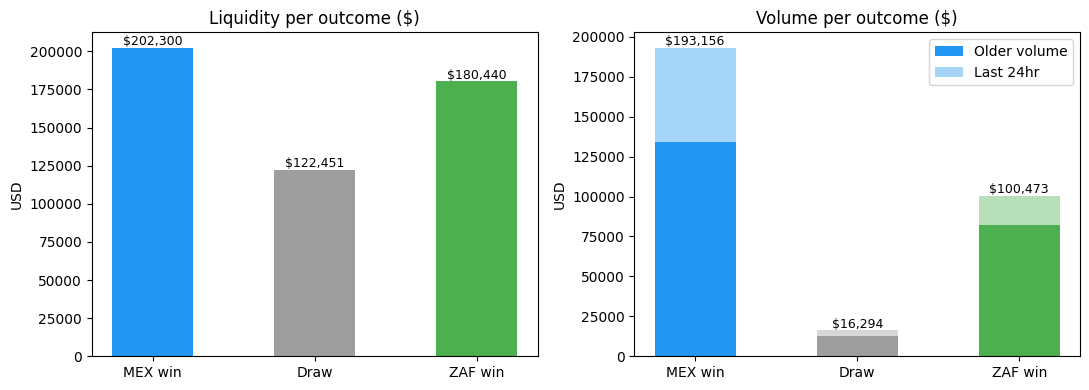

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

outcomes = ["MEX win", "Draw", "ZAF win"]
liquidity = [202300, 122451, 180440]
volume    = [193156, 16294, 100473]
colors    = ["#2196F3", "#9E9E9E", "#4CAF50"]

# ── Left: liquidity ───────────────────────────────────────────
bars = axes[0].bar(outcomes, liquidity, color=colors, width=0.5)
axes[0].set_title("Liquidity per outcome ($)")
axes[0].set_ylabel("USD")
for bar, val in zip(bars, liquidity):
    axes[0].annotate(f"${val:,.0f}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500),
                     ha="center", fontsize=9)

# ── Right: volume breakdown ───────────────────────────────────
vol_24hr = [59197, 3290, 18026]
vol_rest  = [v - v24 for v, v24 in zip(volume, vol_24hr)]

axes[1].bar(outcomes, vol_rest,  color=colors, width=0.5, label="Older volume")
axes[1].bar(outcomes, vol_24hr,  color=colors, width=0.5, bottom=vol_rest,
            alpha=0.4, label="Last 24hr")
axes[1].set_title("Volume per outcome ($)")
axes[1].set_ylabel("USD")
axes[1].legend()
for i, (val, v24) in enumerate(zip(volume, vol_24hr)):
    axes[1].annotate(f"${val:,.0f}",
                     (i, val + 1500),
                     ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Section 3. Supabase - Catalog Discovery

Supabase hosts the historical stats database.
Before fetching any data, we ask the catalog what tables exist

In [28]:
r = requests.get(
    f"{SUPABASE}/rest/v1/catalog_full",
    params={
        "select": "table_name,category,row_count,table_description",
        "order":  "category,table_name",
    },
    headers=H_PUBLIC, timeout=10,
)
r.raise_for_status()

catalog = r.json()

print(f"HTTP {r.status_code} OK")
print(f"Total tables in catalog: {len(catalog)}\n")
for t in catalog:
    desc = (t.get("table_description") or "-").replace("\n", " ")[:60]
    cat  = t.get("category") or "?"
    print(f"  [{cat:11s}] {t['table_name']:30s}  rows={t['row_count']:>5d}  - {desc}")

HTTP 200 OK
Total tables in catalog: 14

  [checkpoint ] d_checkpoint_minutes            rows=  130  - Records the actual end minute and period for each checkpoint
  [checkpoint ] d_checkpoint_runs               rows=  130  - One row per checkpoint processing job run, capturing the exe
  [checkpoint ] d_checkpoint_snapshot           rows=  260  - One row per team per match checkpoint (HT, FT, ET1, ET2) cap
  [checkpoint ] d_match_scores                  rows=  206  - One row per match checkpoint records the final or halftime s
  [dimension  ] dim_checkpoint                  rows=    4  - One row per checkpoint in a match timeline, containing the c
  [dimension  ] dim_match                       rows=   65  - Dimension table storing one row per football match, containi
  [priors     ] ads_a_country_struct            rows=   66  - Country-level prior data capturing each nation's most recent
  [priors     ] ads_a_country_style             rows=   71  - One row per country containing aggre

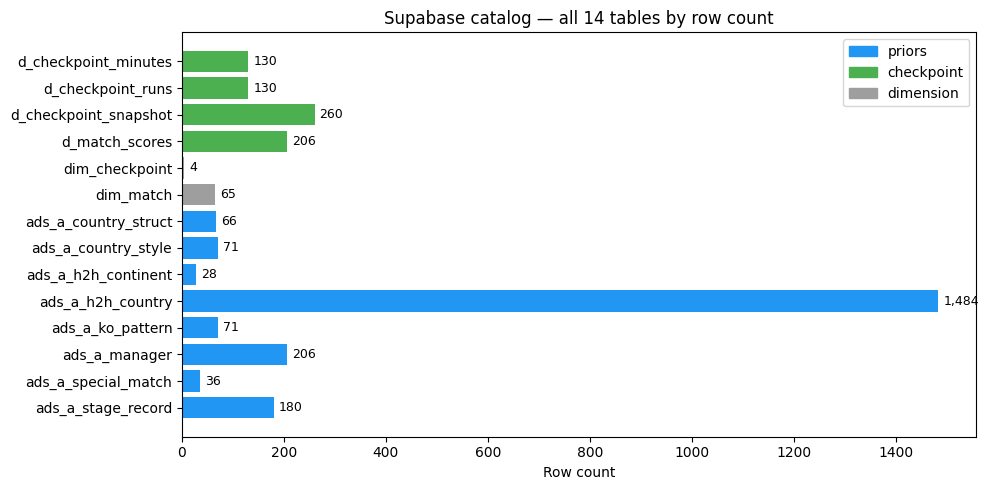

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

df_catalog = pd.DataFrame(catalog)
colors_map = {"priors": "#2196F3", "checkpoint": "#4CAF50", "dimension": "#9E9E9E"}
bar_colors = [colors_map.get(c, "#ccc") for c in df_catalog["category"]]

bars = ax.barh(df_catalog["table_name"], df_catalog["row_count"], color=bar_colors)
ax.set_xlabel("Row count")
ax.set_title("Supabase catalog — all 14 tables by row count")
ax.invert_yaxis()

for bar, val in zip(bars, df_catalog["row_count"]):
    ax.annotate(f"{val:,}",
                (bar.get_width() + 10, bar.get_y() + bar.get_height() / 2),
                va="center", fontsize=9)

patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=patches)

plt.tight_layout()
plt.show()

### Section 3a. Priors - ads_a_country_style

Playing style indicators per country - set piece efficiency, goals per game in group stage vs knockout stage.

In [30]:
r = requests.get(
    f"{SUPABASE}/rest/v1/ads_a_country_style",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_style = pd.DataFrame(r.json())
print(f"Shape: {df_style.shape}")
print(f"\nColumns: {list(df_style.columns)}\n")
display(df_style.head())

Shape: (71, 10)

Columns: ['country_id', 'set_piece_shots', 'set_piece_goals', 'conversion_rate', 'group_matches', 'group_goals_against', 'ko_matches', 'ko_goals_against', 'group_gpg', 'ko_gpg']



,country_id,set_piece_shots,set_piece_goals,conversion_rate,group_matches,group_goals_against,ko_matches,ko_goals_against,group_gpg,ko_gpg
0,255,18,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,3,13,2,0.153846,NaN,NaN,NaN,NaN,NaN,NaN
2,11,147,12,0.081633,15.0,16.0,8.0,11.0,1.066667,1.375000
3,14,128,11,0.085938,12.0,17.0,6.0,8.0,1.416667,1.333333
4,15,91,10,0.109890,9.0,8.0,3.0,6.0,0.888889,2.000000


In [31]:
# Filter to just our two teams
df_our_teams = df_style[df_style["country_id"].isin([147, 211])].copy()
df_our_teams["team"] = df_our_teams["country_id"].map({147: "MEX", 211: "ZAF"})

display(df_our_teams)

,country_id,set_piece_shots,set_piece_goals,conversion_rate,group_matches,group_goals_against,ko_matches,ko_goals_against,group_gpg,ko_gpg,team
35,147,94,2,0.021277,9.0,8.0,1.0,2.0,0.888889,2.0,MEX
57,211,26,2,0.076923,6.0,14.0,1.0,2.0,2.333333,2.0,ZAF


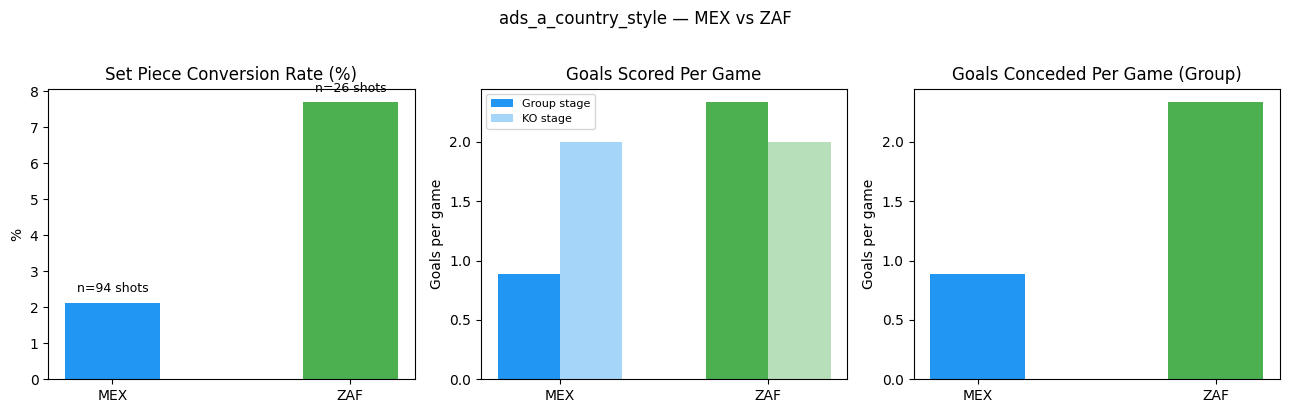

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

mex = df_our_teams[df_our_teams["team"] == "MEX"].iloc[0]
zaf = df_our_teams[df_our_teams["team"] == "ZAF"].iloc[0]
colors = ["#2196F3", "#4CAF50"]

# ── Left: set piece conversion rate ───────────────────────────
axes[0].bar(["MEX", "ZAF"],
            [mex["conversion_rate"] * 100, zaf["conversion_rate"] * 100],
            color=colors, width=0.4)
axes[0].set_title("Set Piece Conversion Rate (%)")
axes[0].set_ylabel("%")
axes[0].annotate(f"n={int(mex['set_piece_shots'])} shots", (0, mex["conversion_rate"]*100 + 0.3), ha="center", fontsize=9)
axes[0].annotate(f"n={int(zaf['set_piece_shots'])} shots", (1, zaf["conversion_rate"]*100 + 0.3), ha="center", fontsize=9)

# ── Middle: goals scored per game ─────────────────────────────
x = [0, 1]
width = 0.3
axes[1].bar([i - width/2 for i in x],
            [mex["group_gpg"], zaf["group_gpg"]],
            width=width, color=colors, label="Group stage")
axes[1].bar([i + width/2 for i in x],
            [mex["ko_gpg"], zaf["ko_gpg"]],
            width=width, color=colors, alpha=0.4, label="KO stage")
axes[1].set_title("Goals Scored Per Game")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["MEX", "ZAF"])
axes[1].legend(fontsize=8)
axes[1].set_ylabel("Goals per game")

# ── Right: goals conceded per game ────────────────────────────
axes[2].bar(["MEX", "ZAF"],
            [mex["group_goals_against"] / mex["group_matches"],
             zaf["group_goals_against"] / zaf["group_matches"]],
            color=colors, width=0.4)
axes[2].set_title("Goals Conceded Per Game (Group)")
axes[2].set_ylabel("Goals per game")

plt.suptitle("ads_a_country_style — MEX vs ZAF", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Section 3b. Priors - ads_a_country_struct

Country-level structural data (recent form, squad strength indicators).

In [33]:
r = requests.get(
    f"{SUPABASE}/rest/v1/ads_a_country_struct",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_struct = pd.DataFrame(r.json())
print(f"Shape: {df_struct.shape}")
print(f"\nColumns: {list(df_struct.columns)}\n")
display(df_struct.head())

Shape: (66, 3)

Columns: ['country_id', 'last_final_date', 'years_since_final']



,country_id,last_final_date,years_since_final
0,3,NaN,NaN
1,11,2024-07-15,1.859001
2,14,NaN,NaN
3,15,NaN,NaN
4,22,NaN,NaN


In [34]:
# Filter to our two teams
df_struct_teams = df_struct[df_struct["country_id"].isin([147, 211])].copy()
df_struct_teams["team"] = df_struct_teams["country_id"].map({147: "MEX", 211: "ZAF"})

display(df_struct_teams)

# Also check how many countries have a final date vs NaN
total = len(df_struct)
has_final = df_struct["last_final_date"].notna().sum()
print(f"\nCountries that have reached a final: {has_final}/{total}")
print(f"Countries that have never reached a final: {total - has_final}/{total}")

,country_id,last_final_date,years_since_final,team
32,147,NaN,NaN,MEX
53,211,NaN,NaN,ZAF



Countries that have reached a final: 10/66
Countries that have never reached a final: 56/66


### Section 3c. Priors — ads_a_h2h_country

Head-to-head records between every country pair.

In [38]:
r = requests.get(
    f"{SUPABASE}/rest/v1/ads_a_h2h_country",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_h2h = pd.DataFrame(r.json())
print(f"Shape: {df_h2h.shape}")
print(f"\nColumns: {list(df_h2h.columns)}\n")
display(df_h2h.head())

Shape: (1000, 15)

Columns: ['country_id_a', 'country_id_b', 'match_scope', 'country_name_a', 'country_name_b', 'total_matches', 'wins_a_raw', 'draws_raw', 'losses_a_raw', 'wins_a_weighted', 'draws_weighted', 'losses_a_weighted', 'total_weight', 'win_rate_a_weighted', 'last_meeting_date']



,country_id_a,country_id_b,match_scope,country_name_a,country_name_b,total_matches,wins_a_raw,draws_raw,losses_a_raw,wins_a_weighted,draws_weighted,losses_a_weighted,total_weight,win_rate_a_weighted,last_meeting_date
0,11,22,all,Argentina,Belgium,1,1,0,0,2,0,0,2,1.0,1986-06-26
1,11,31,all,Argentina,Brazil,1,1,0,0,2,0,0,2,1.0,1990-06-24
2,11,85,all,Argentina,Germany,1,1,0,0,2,0,0,2,1.0,1986-06-29
3,22,11,all,Belgium,Argentina,1,0,0,1,0,0,2,2,0.0,1986-06-26
4,31,11,all,Brazil,Argentina,1,0,0,1,0,0,2,2,0.0,1990-06-24


In [39]:
# Find all rows involving both MEX (147) and ZAF (211)
mask = (
    (df_h2h["country_id_a"].isin([147, 211])) &
    (df_h2h["country_id_b"].isin([147, 211]))
)
df_mex_zaf = df_h2h[mask].copy()

print(f"H2H rows found for MEX vs ZAF: {len(df_mex_zaf)}\n")
display(df_mex_zaf)

H2H rows found for MEX vs ZAF: 0



,country_id_a,country_id_b,match_scope,country_name_a,country_name_b,total_matches,wins_a_raw,draws_raw,losses_a_raw,wins_a_weighted,draws_weighted,losses_a_weighted,total_weight,win_rate_a_weighted,last_meeting_date


In [40]:
# Search by country name instead of ID
mask_name = (
    (df_h2h["country_name_a"].isin(["Mexico", "South Africa"])) &
    (df_h2h["country_name_b"].isin(["Mexico", "South Africa"]))
)
df_name_search = df_h2h[mask_name]
print(f"Rows found by name: {len(df_name_search)}")
display(df_name_search)

# Also check — are Mexico and South Africa even in this table at all?
print("\nAll rows mentioning Mexico:")
display(df_h2h[df_h2h["country_name_a"] == "Mexico"].head(3))

print("\nAll rows mentioning South Africa:")
display(df_h2h[df_h2h["country_name_a"] == "South Africa"].head(3))

Rows found by name: 0


,country_id_a,country_id_b,match_scope,country_name_a,country_name_b,total_matches,wins_a_raw,draws_raw,losses_a_raw,wins_a_weighted,draws_weighted,losses_a_weighted,total_weight,win_rate_a_weighted,last_meeting_date



All rows mentioning Mexico:


,country_id_a,country_id_b,match_scope,country_name_a,country_name_b,total_matches,wins_a_raw,draws_raw,losses_a_raw,wins_a_weighted,draws_weighted,losses_a_weighted,total_weight,win_rate_a_weighted,last_meeting_date
430,147,11,all,Mexico,Argentina,1,0,0,1,0,0,2,2,0.0,2022-11-26
431,147,31,all,Mexico,Brazil,1,0,0,1,0,0,2,2,0.0,2018-07-02
432,147,65,all,Mexico,Ecuador,1,0,1,0,0,2,0,2,0.0,2024-07-01



All rows mentioning South Africa:


,country_id_a,country_id_b,match_scope,country_name_a,country_name_b,total_matches,wins_a_raw,draws_raw,losses_a_raw,wins_a_weighted,draws_weighted,losses_a_weighted,total_weight,win_rate_a_weighted,last_meeting_date
620,211,11,all,South Africa,Argentina,1,0,1,0,0,2,0,2,0.0,2023-07-28
621,211,46,all,South Africa,China,1,0,0,1,0,0,2,2,0.0,2019-06-13
622,211,85,all,South Africa,Germany,1,0,0,1,0,0,2,2,0.0,2019-06-17


In [41]:
# How many rows does Mexico (147) appear in as country_id_a?
mex_h2h = df_h2h[df_h2h["country_id_a"] == 147]
print(f"Mexico rows in h2h (as country_a): {len(mex_h2h)}")
display(mex_h2h[["country_name_a", "country_name_b", "match_scope", "total_matches", "last_meeting_date"]])

Mexico rows in h2h (as country_a): 10


,country_name_a,country_name_b,match_scope,total_matches,last_meeting_date
430,Mexico,Argentina,all,1,2022-11-26
431,Mexico,Brazil,all,1,2018-07-02
432,Mexico,Ecuador,all,1,2024-07-01
433,Mexico,Germany,all,1,2018-06-17
434,Mexico,Jamaica,all,1,2024-06-23
435,Mexico,Korea (South),all,1,2018-06-23
436,Mexico,Poland,all,1,2022-11-22
437,Mexico,Saudi Arabia,all,1,2022-11-30
438,Mexico,Sweden,all,1,2018-06-27
439,Mexico,Venezuela (Bolivarian Republic),all,1,2024-06-27


In [43]:
r = requests.get(
    f"{SUPABASE}/rest/v1/dim_match",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_matches = pd.DataFrame(r.json())
print(f"Shape: {df_matches.shape}")
print(f"\nColumns: {list(df_matches.columns)}\n")
display(df_matches.head(5))

Shape: (65, 12)

Columns: ['match_id', 'kickoff_at', 'competition_id', 'competition_name', 'team_id_a', 'team_name_a', 'team_id_b', 'team_name_b', 'country_id_a', 'country_id_b', 'stage_canonical', 'is_knockout']



,match_id,kickoff_at,competition_id,competition_name,team_id_a,team_name_a,team_id_b,team_name_b,country_id_a,country_id_b,stage_canonical,is_knockout
0,18494101,2022-11-29T15:00:00+00:00,732,World Cup,18573,Ecuador,18558,Senegal,459,200,group,False
1,18494063,2022-11-29T19:00:00+00:00,732,World Cup,18721,Wales,18645,England,515,462,group,False
2,18494072,2022-11-30T15:00:00+00:00,732,World Cup,18730,Australia,18583,Denmark,98,320,group,False
3,18494068,2022-11-30T19:00:00+00:00,732,World Cup,18562,Saudi Arabia,18576,Mexico,35376,458,group,False
4,18494071,2022-11-30T15:00:00+00:00,732,World Cup,18554,Tunisia,18647,France,1439,17,group,False


In [44]:
print("Unique competitions in dim_match:")
print(df_matches[["competition_id", "competition_name"]].drop_duplicates())

print("\nDate range:")
print(f"  Earliest: {df_matches['kickoff_at'].min()}")
print(f"  Latest:   {df_matches['kickoff_at'].max()}")

print(f"\nTotal matches: {len(df_matches)}")
print(f"Group stage:   {len(df_matches[df_matches['is_knockout'] == False])}")
print(f"Knockout:      {len(df_matches[df_matches['is_knockout'] == True])}")

Unique competitions in dim_match:
    competition_id competition_name
0              732        World Cup
64             384          Serie A

Date range:
  Earliest: 2022-11-20T16:00:00+00:00
  Latest:   2026-05-22T18:45:00+00:00

Total matches: 65
Group stage:   49
Knockout:      16


In [45]:
mex_matches = df_matches[
    (df_matches["country_id_a"] == 147) | 
    (df_matches["country_id_b"] == 147)
]
zaf_matches = df_matches[
    (df_matches["country_id_a"] == 211) | 
    (df_matches["country_id_b"] == 211)
]

print(f"Mexico matches in database   : {len(mex_matches)}")
display(mex_matches[["kickoff_at", "team_name_a", "team_name_b", "stage_canonical", "is_knockout"]])

print(f"\nSouth Africa matches in database: {len(zaf_matches)}")
display(zaf_matches[["kickoff_at", "team_name_a", "team_name_b", "stage_canonical", "is_knockout"]])

Mexico matches in database   : 0


,kickoff_at,team_name_a,team_name_b,stage_canonical,is_knockout



South Africa matches in database: 0


,kickoff_at,team_name_a,team_name_b,stage_canonical,is_knockout


In [46]:
# Search by team name instead
mex_matches = df_matches[
    df_matches["team_name_a"].str.contains("Mexico", case=False, na=False) |
    df_matches["team_name_b"].str.contains("Mexico", case=False, na=False)
]

zaf_matches = df_matches[
    df_matches["team_name_a"].str.contains("South Africa", case=False, na=False) |
    df_matches["team_name_b"].str.contains("South Africa", case=False, na=False)
]

print(f"Mexico matches found by name: {len(mex_matches)}")
display(mex_matches[["kickoff_at", "team_name_a", "team_name_b", "country_id_a", "country_id_b", "stage_canonical"]])

print(f"\nSouth Africa matches found by name: {len(zaf_matches)}")
display(zaf_matches[["kickoff_at", "team_name_a", "team_name_b", "country_id_a", "country_id_b", "stage_canonical"]])

Mexico matches found by name: 3


,kickoff_at,team_name_a,team_name_b,country_id_a,country_id_b,stage_canonical
3,2022-11-30T19:00:00+00:00,Saudi Arabia,Mexico,35376,458,group
10,2022-11-22T16:00:00+00:00,Mexico,Poland,458,2,group
38,2022-11-26T19:00:00+00:00,Argentina,Mexico,44,458,group



South Africa matches found by name: 0


,kickoff_at,team_name_a,team_name_b,country_id_a,country_id_b,stage_canonical


In [47]:
# Correct country_id for Mexico in this database is 458
mex_matches_correct = df_matches[
    (df_matches["country_id_a"] == 458) |
    (df_matches["country_id_b"] == 458)
]

print("Mexico's 3 matches:")
display(mex_matches_correct[["kickoff_at", "team_name_a", "team_name_b", 
                              "stage_canonical", "is_knockout"]])

Mexico's 3 matches:


,kickoff_at,team_name_a,team_name_b,stage_canonical,is_knockout
3,2022-11-30T19:00:00+00:00,Saudi Arabia,Mexico,group,False
10,2022-11-22T16:00:00+00:00,Mexico,Poland,group,False
38,2022-11-26T19:00:00+00:00,Argentina,Mexico,group,False


### Section 3e. Checkpoint tables - live match snapshots

The d_* tables capture match stats at specific checkpoints:
HT (half time), FT (full time), ET1, ET2.
Let's explore what's inside for Mexico's 3 matches.

In [48]:
r = requests.get(
    f"{SUPABASE}/rest/v1/d_checkpoint_snapshot",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_snap = pd.DataFrame(r.json())
print(f"Shape: {df_snap.shape}")
print(f"\nColumns: {list(df_snap.columns)}\n")
display(df_snap.head(3))

Shape: (260, 51)

Columns: ['match_id', 'checkpoint_code', 'team_id', 'is_home', 'opponent_team_id', 'match_minute', 'pulled_at', 'seg_duration_min', 'seg_goals', 'cum_goals', 'seg_red_cards', 'cum_red_cards', 'is_down_to_10', 'red_card_playbook_loaded', 'seg_yellow_cards', 'cum_yellow_cards', 'seg_subs_count', 'seg_key_role_subs_count', 'cum_subs_used', 'subs_remaining', 'seg_penalties_awarded', 'seg_penalties_against', 'raw_cum_xg', 'cum_xg', 'seg_xg', 'xg_diff_vs_opponent', 'seg_xg_diff_vs_opponent', 'raw_cum_possession_pct', 'cum_possession_pct', 'seg_possession_pct', 'raw_cum_shots_total', 'raw_cum_shots_on_target', 'cum_shots_total', 'cum_shots_on_target', 'cum_shot_on_target_pct', 'seg_shots_total', 'raw_cum_passes_total', 'raw_cum_passes_accurate', 'cum_pass_accuracy_pct', 'raw_cum_corners', 'raw_cum_offsides', 'raw_cum_fouls', 'cum_dangerous_attacks', 'seg_dangerous_attacks', 'seg_avg_def_line_height_m', 'def_line_trend', 'seg_avg_ppda', 'ppda_trend', 'raw_extras', 'seg_goal_c

,match_id,checkpoint_code,team_id,is_home,opponent_team_id,match_minute,pulled_at,seg_duration_min,seg_goals,cum_goals,...,raw_cum_fouls,cum_dangerous_attacks,seg_dangerous_attacks,seg_avg_def_line_height_m,def_line_trend,seg_avg_ppda,ppda_trend,raw_extras,seg_goal_count,seg_penalty_count
0,18452325,HT,18647,False,18644,45,2026-05-21T10:20:49.715132+00:00,45,0,0,...,None,0,0,None,None,None,None,"{'cum_shots_blocked': None, 'cum_shots_off_tar...",0,0
1,18452325,HT,18644,True,18647,45,2026-05-21T10:20:49.715132+00:00,45,1,1,...,None,0,0,None,None,None,None,"{'cum_shots_blocked': None, 'cum_shots_off_tar...",1,1
2,18452327,HT,18644,True,18588,45,2026-05-21T10:22:16.276812+00:00,45,1,1,...,None,0,0,None,None,None,None,"{'cum_shots_blocked': None, 'cum_shots_off_tar...",1,1


In [49]:
# See all columns
print("All columns:")
for col in df_snap.columns:
    print(f"  {col}")

All columns:
  match_id
  checkpoint_code
  team_id
  is_home
  opponent_team_id
  match_minute
  pulled_at
  seg_duration_min
  seg_goals
  cum_goals
  seg_red_cards
  cum_red_cards
  is_down_to_10
  red_card_playbook_loaded
  seg_yellow_cards
  cum_yellow_cards
  seg_subs_count
  seg_key_role_subs_count
  cum_subs_used
  subs_remaining
  seg_penalties_awarded
  seg_penalties_against
  raw_cum_xg
  cum_xg
  seg_xg
  xg_diff_vs_opponent
  seg_xg_diff_vs_opponent
  raw_cum_possession_pct
  cum_possession_pct
  seg_possession_pct
  raw_cum_shots_total
  raw_cum_shots_on_target
  cum_shots_total
  cum_shots_on_target
  cum_shot_on_target_pct
  seg_shots_total
  raw_cum_passes_total
  raw_cum_passes_accurate
  cum_pass_accuracy_pct
  raw_cum_corners
  raw_cum_offsides
  raw_cum_fouls
  cum_dangerous_attacks
  seg_dangerous_attacks
  seg_avg_def_line_height_m
  def_line_trend
  seg_avg_ppda
  ppda_trend
  raw_extras
  seg_goal_count
  seg_penalty_count


In [50]:
# Get Mexico's match IDs
mex_match_ids = mex_matches_correct["match_id"].tolist()
print(f"Mexico match IDs: {mex_match_ids}")

# Filter snapshot to Mexico matches at FT only
mex_snap = df_snap[
    (df_snap["match_id"].isin(mex_match_ids)) &
    (df_snap["checkpoint_code"] == "FT") &
    (df_snap["team_id"] == 458)   # Mexico's team_id
].copy()

print(f"\nRows found: {len(mex_snap)}")
display(mex_snap[["match_id", "checkpoint_code", "is_home",
                   "cum_goals", "cum_xg", "cum_shots_total",
                   "cum_shots_on_target", "cum_possession_pct",
                   "cum_pass_accuracy_pct", "cum_yellow_cards"]].reset_index(drop=True))

Mexico match IDs: [18494068, 18493997, 18494065]

Rows found: 0


,match_id,checkpoint_code,is_home,cum_goals,cum_xg,cum_shots_total,cum_shots_on_target,cum_possession_pct,cum_pass_accuracy_pct,cum_yellow_cards


In [51]:
# What match_ids are in the snapshot table?
print("Match IDs in snapshot table:")
print(sorted(df_snap["match_id"].unique()))

print(f"\nMexico match IDs we're looking for:")
print(mex_match_ids)

# Are any of our match IDs even in the snapshot?
overlap = set(mex_match_ids) & set(df_snap["match_id"].unique())
print(f"\nOverlap: {overlap}")

Match IDs in snapshot table:
[np.int64(18452325), np.int64(18452326), np.int64(18452327), np.int64(18452328), np.int64(18452329), np.int64(18452330), np.int64(18452331), np.int64(18452332), np.int64(18452333), np.int64(18452334), np.int64(18452335), np.int64(18452336), np.int64(18452337), np.int64(18452338), np.int64(18452339), np.int64(18452340), np.int64(18452341), np.int64(18493993), np.int64(18493994), np.int64(18493995), np.int64(18493996), np.int64(18493997), np.int64(18493998), np.int64(18493999), np.int64(18494000), np.int64(18494001), np.int64(18494002), np.int64(18494003), np.int64(18494004), np.int64(18494005), np.int64(18494006), np.int64(18494007), np.int64(18494061), np.int64(18494062), np.int64(18494063), np.int64(18494064), np.int64(18494065), np.int64(18494066), np.int64(18494067), np.int64(18494068), np.int64(18494069), np.int64(18494070), np.int64(18494071), np.int64(18494072), np.int64(18494073), np.int64(18494074), np.int64(18494075), np.int64(18494076), np.int64(1

In [52]:
# Look at what team_ids appear in Mexico's 3 matches
mex_in_snap = df_snap[df_snap["match_id"].isin(mex_match_ids)]
print(f"Rows found for Mexico match IDs: {len(mex_in_snap)}")
print(f"\nUnique team_ids in these matches:")
print(mex_in_snap["team_id"].unique())

# Cross reference with dim_match to identify which is Mexico
print("\nFrom dim_match, Mexico's matches:")
display(mex_matches_correct[["match_id", "team_name_a", "team_id_a", "team_name_b", "team_id_b"]])

Rows found for Mexico match IDs: 12

Unique team_ids in these matches:
[18576 18699 18644 18562]

From dim_match, Mexico's matches:


,match_id,team_name_a,team_id_a,team_name_b,team_id_b
3,18494068,Saudi Arabia,18562,Mexico,18576
10,18493997,Mexico,18576,Poland,18699
38,18494065,Argentina,18644,Mexico,18576


In [53]:
# Filter to Mexico (team_id 18576) at FT checkpoint
mex_snap = df_snap[
    (df_snap["match_id"].isin(mex_match_ids)) &
    (df_snap["checkpoint_code"] == "FT") &
    (df_snap["team_id"] == 18576)
].copy()

# Add opponent name for context
match_lookup = {
    18494068: "vs Saudi Arabia",
    18493997: "vs Poland",
    18494065: "vs Argentina",
}
mex_snap["match"] = mex_snap["match_id"].map(match_lookup)

print(f"Rows found: {len(mex_snap)}")
display(mex_snap[["match", "is_home", "cum_goals", "cum_xg",
                   "cum_shots_total", "cum_shots_on_target",
                   "cum_possession_pct", "cum_pass_accuracy_pct",
                   "cum_yellow_cards"]].reset_index(drop=True))

Rows found: 3


,match,is_home,cum_goals,cum_xg,cum_shots_total,cum_shots_on_target,cum_possession_pct,cum_pass_accuracy_pct,cum_yellow_cards
0,vs Poland,True,0,NaN,11,4,61.0,0.835729,2
1,vs Argentina,False,0,NaN,4,1,41.0,0.767568,4
2,vs Saudi Arabia,False,2,NaN,26,11,61.0,0.751174,1


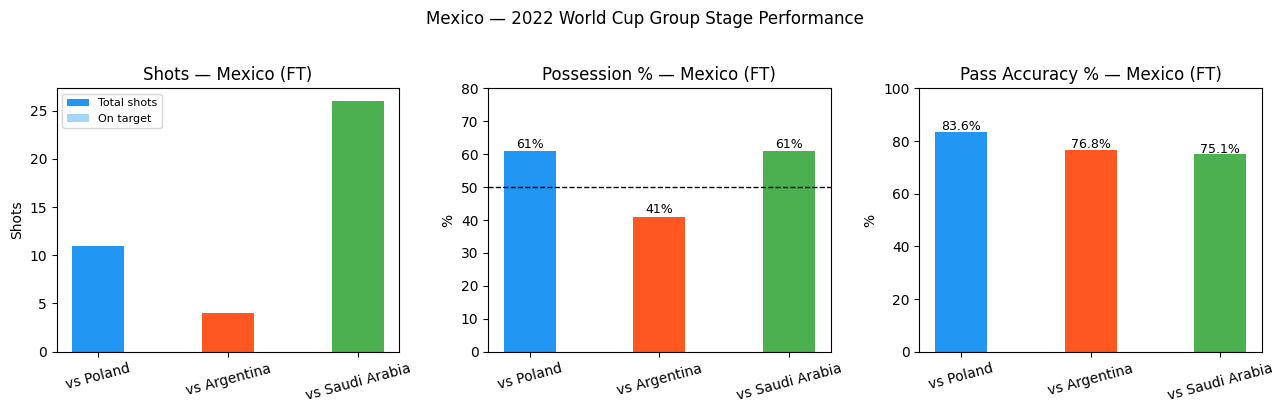

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

matches = mex_snap["match"].tolist()
colors  = ["#2196F3", "#FF5722", "#4CAF50"]

# ── Left: shots ───────────────────────────────────────────────
axes[0].bar(matches, mex_snap["cum_shots_total"], color=colors, width=0.4, label="Total shots")
axes[0].bar(matches, mex_snap["cum_shots_on_target"], color=colors, width=0.4, alpha=0.4, label="On target")
axes[0].set_title("Shots — Mexico (FT)")
axes[0].set_ylabel("Shots")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=15)

# ── Middle: possession ────────────────────────────────────────
axes[1].bar(matches, mex_snap["cum_possession_pct"], color=colors, width=0.4)
axes[1].axhline(50, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Possession % — Mexico (FT)")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 80)
axes[1].tick_params(axis="x", rotation=15)
for i, val in enumerate(mex_snap["cum_possession_pct"]):
    axes[1].annotate(f"{val:.0f}%", (i, val + 1), ha="center", fontsize=9)

# ── Right: pass accuracy ──────────────────────────────────────
axes[2].bar(matches, mex_snap["cum_pass_accuracy_pct"] * 100, color=colors, width=0.4)
axes[2].set_title("Pass Accuracy % — Mexico (FT)")
axes[2].set_ylabel("%")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis="x", rotation=15)
for i, val in enumerate(mex_snap["cum_pass_accuracy_pct"] * 100):
    axes[2].annotate(f"{val:.1f}%", (i, val + 0.5), ha="center", fontsize=9)

plt.suptitle("Mexico — 2022 World Cup Group Stage Performance", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [55]:
# What countries are actually at country_id 147 and 211 in ads_a_country_style?
df_style[df_style["country_id"].isin([147, 211])]

,country_id,set_piece_shots,set_piece_goals,conversion_rate,group_matches,group_goals_against,ko_matches,ko_goals_against,group_gpg,ko_gpg
35,147,94,2,0.021277,9.0,8.0,1.0,2.0,0.888889,2.0
57,211,26,2,0.076923,6.0,14.0,1.0,2.0,2.333333,2.0


In [56]:
# Build a country_id → team_name lookup from dim_match
id_to_name = {}
for _, row in df_matches.iterrows():
    id_to_name[row["country_id_a"]] = row["team_name_a"]
    id_to_name[row["country_id_b"]] = row["team_name_b"]

print("What are country_id 147 and 211?")
print(f"  147 → {id_to_name.get(147, 'NOT FOUND')}")
print(f"  211 → {id_to_name.get(211, 'NOT FOUND')}")

# Print full lookup for reference
print("\nFull country_id → name mapping from dim_match:")
for cid, name in sorted(id_to_name.items()):
    print(f"  {cid:5d} → {name}")

What are country_id 147 and 211?
  147 → NOT FOUND
  211 → NOT FOUND

Full country_id → name mapping from dim_match:
      2 → Poland
      5 → Brazil
     11 → Germany
     17 → France
     20 → Portugal
     32 → Spain
     38 → Netherlands
     44 → Argentina
     62 → Switzerland
     98 → Australia
    158 → Uruguay
    200 → Senegal
    251 → Atalanta
    266 → Croatia
    296 → Serbia
    320 → Denmark
    458 → Mexico
    459 → Ecuador
    462 → England
    468 → Ghana
    479 → Japan
    488 → Iran
    515 → Wales
    556 → Belgium
    593 → Cameroon
    712 → Korea Republic
   1004 → Canada
   1424 → Morocco
   1439 → Tunisia
   1739 → Costa Rica
   3483 → United States
  35376 → Saudi Arabia
  74505 → Qatar


In [57]:
print("Mexico (458) in ads_a_country_style:")
display(df_style[df_style["country_id"] == 458])

print("\nSouth Africa (any ID) in ads_a_country_style:")
# Check all IDs we know for ZAF
display(df_style[df_style["country_id"].isin([211, 146, 18555])])

Mexico (458) in ads_a_country_style:


,country_id,set_piece_shots,set_piece_goals,conversion_rate,group_matches,group_goals_against,ko_matches,ko_goals_against,group_gpg,ko_gpg



South Africa (any ID) in ads_a_country_style:


,country_id,set_piece_shots,set_piece_goals,conversion_rate,group_matches,group_goals_against,ko_matches,ko_goals_against,group_gpg,ko_gpg
57,211,26,2,0.076923,6.0,14.0,1.0,2.0,2.333333,2.0
